In [10]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My\ Drive/Colab\ Notebooks/WignerCamp2026
    !pip install optuna --quiet
except:
    IN_COLAB = False
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running on Local computer


In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

from artificial_dataset import ClassifierMetrics, make_anomaly_dataset

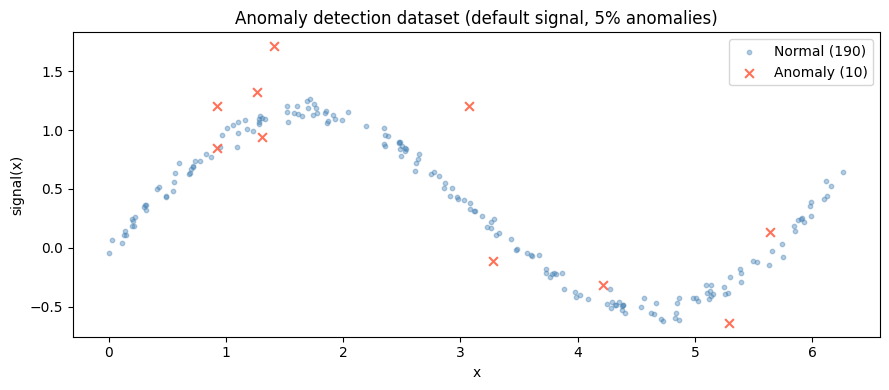

In [12]:
x, Y, labels = make_anomaly_dataset(
    n_samples=200, anomaly_fraction=0.05, random_state=0
)

normal = labels == 0
anomaly = labels == 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    x[normal],
    Y[normal, 0],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    x[anomaly],
    Y[anomaly, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Anomaly detection dataset (default signal, 5% anomalies)")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
print(f"x:")
print(x.shape)
print(x[:5])
print(f"Y:")
print(Y.shape)
print(Y[:5])
print(f"class:")
print(labels.shape)
print(labels[:5])

x:
torch.Size([200])
tensor([0.0078, 0.0322, 0.1117, 0.1280, 0.1403])
Y:
torch.Size([200, 1])
tensor([[-0.0435],
        [ 0.0646],
        [ 0.0390],
        [ 0.1101],
        [ 0.1407]])
class:
torch.Size([200])
tensor([0, 0, 0, 0, 0])


In [14]:
peaks, properties = find_peaks(Y[:, 0])
print(peaks, properties)

[  1   4   7  12  16  22  28  30  33  37  39  41  44  48  52  57  60  62
  64  68  71  74  79  82  84  86  89  93  95  98 100 104 106 108 112 114
 116 119 123 128 130 134 136 138 140 143 147 150 153 158 160 162 164 168
 171 173 176 179 182 184 186 190 193 196] {}


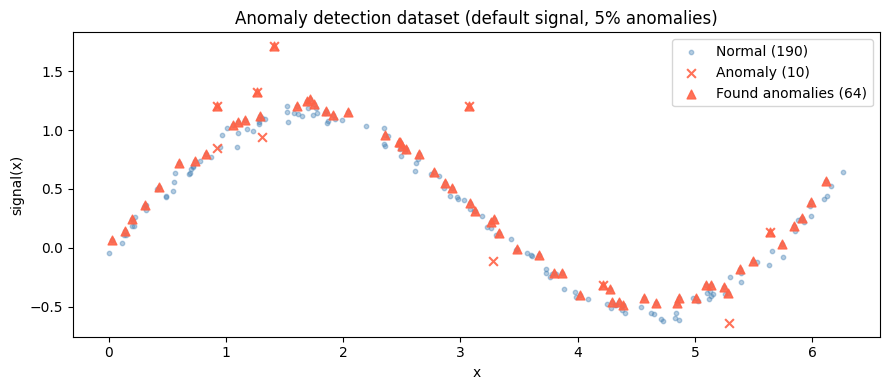

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    x[normal],
    Y[normal, 0],
    s=10,
    alpha=0.4,
    color="steelblue",
    label=f"Normal ({normal.sum().item()})",
)
ax.scatter(
    x[anomaly],
    Y[anomaly, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="x",
    label=f"Anomaly ({anomaly.sum().item()})",
)
ax.scatter(
    x[peaks],
    Y[peaks, 0],
    s=40,
    alpha=0.9,
    color="tomato",
    marker="^",
    label=f"Found anomalies ({peaks.shape[0]})",
)
ax.set_xlabel("x")
ax.set_ylabel("signal(x)")
ax.set_title("Anomaly detection dataset (default signal, 5% anomalies)")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
y_pred = torch.zeros(Y.shape[0])
y_pred[peaks] = 1

m = ClassifierMetrics(y_true=labels, y_pred=y_pred)

print(f"Accuracy  : {m.accuracy:.3f}")
print(f"Precision : {m.precision:.3f}")
print(f"Recall    : {m.recall:.3f}")
print(f"F1 score  : {m.f1_score:.3f}")
print()
print("Confusion matrix (rows = true, cols = predicted):")
print(m.confusion_matrix)


Accuracy  : 0.690
Precision : 0.532
Recall    : 0.647
F1 score  : 0.486

Confusion matrix (rows = true, cols = predicted):
tensor([[132,  58],
        [  4,   6]])
